In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from statannotations.Annotator import Annotator
import scipy.stats as stats
import numpy as np
%matplotlib inline
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#import dataframes

#import MZmine feature table
ftable_mzmine = pd.read_csv('/path/Beef_ConjBA_iimn_quant.csv', sep=';', index_col=0)
#import the combined plantmasst table and filter for cosine_raw>=0.7
plantmasst = pd.read_csv('/path/American_Mediterranean_plantMASST_matches.tsv', sep='\t')
#remove analogs
plantmasst = plantmasst[plantmasst['Cosine'] >= 0.7]
plantmasst = plantmasst[(plantmasst['Delta Mass'] >= -0.02) & (plantmasst['Delta Mass'] <= 0.02)]

#import the metadata of the study
metadata = pd.read_csv('/path/Patterson_metadata.csv', sep=';')
#import a dataframe with features with MS2
features_ms2 = pd.read_csv('/path/features_ms2.tsv', sep='\t')


In [ ]:
plantmasst_raw = plantmasst.copy()
plantmasst_full = pd.read_csv('/path/plant_masst_table.csv', sep=',')
plantmasst_taxonomy = pd.read_csv('/path/plant_masst_table_lineage_tree.tsv', sep='\t')
plantmasst_taxonomy = plantmasst_taxonomy.rename(columns={'TaxID': 'Taxa_NCBI'})
plantmasst_taxonomy['Taxa_NCBI'] = plantmasst_taxonomy['Taxa_NCBI'].astype(str)


def load_family_plantmasst(plantmasst_raw, family, plantmasst_full, plantmasst_taxonomy):
    family_plantmasst = plantmasst_raw[plantmasst_raw['Filepath'].isin(plantmasst_full['Filepath'])].copy()
    family_plantmasst = family_plantmasst.drop(columns=['family'], errors='ignore')
    family_plantmasst['Taxa_NCBI'] = family_plantmasst['Taxa_NCBI'].astype(str).str.strip()
    plantmasst_taxonomy = plantmasst_taxonomy.copy()
    plantmasst_taxonomy['Taxa_NCBI'] = plantmasst_taxonomy['Taxa_NCBI'].astype(str).str.strip()
    family_plantmasst = pd.merge(
        family_plantmasst,
        plantmasst_taxonomy[['Taxa_NCBI', 'family']],
        on='Taxa_NCBI',
        how='left',
    )
    family_plantmasst['family'] = family_plantmasst['family'].astype(str).str.strip()
    return family_plantmasst[family_plantmasst['family'].isin([family])]


def preprocess_and_analyze_abundance(ftable_mzmine, plantmasst_family, metadata, features_ms2):
    ftable_mzmine = ftable_mzmine[ftable_mzmine.index.isin(features_ms2['row ID'])].copy()
    plantmasst_filtered = plantmasst_family[
        (plantmasst_family.Blank != 'Yes')
        & (plantmasst_family.QC != 'Yes')
        & (plantmasst_family.MassIVE != 'MSV000083756')
    ]

    valid_scans = set(plantmasst_filtered['Scan'])
    new_columns = {}

    for column in ftable_mzmine.columns:
        column_name_temp = f'{column}_plantmasst'
        new_column = pd.Series(0, index=ftable_mzmine.index)
        matching_rows = (ftable_mzmine[column] != 0) & ftable_mzmine.index.isin(valid_scans)
        new_column[matching_rows] = ftable_mzmine[column]
        new_columns[column_name_temp] = new_column

    ftable_mzmine = pd.concat([ftable_mzmine, pd.DataFrame(new_columns)], axis=1)
    sums = ftable_mzmine.sum(axis=0)
    summed_df = pd.DataFrame({'filename': sums.index, 'total_features': sums.values})
    summed_df['plantmasst_features'] = summed_df['filename'].apply(
        lambda x: summed_df.loc[summed_df['filename'] == f'{x}_plantmasst', 'total_features'].sum()
    )
    summed_df = summed_df[~summed_df['filename'].str.contains('_plantmasst')].reset_index(drop=True)
    summed_df['percentage'] = summed_df['plantmasst_features'] / summed_df['total_features'] * 100
    return pd.merge(summed_df, metadata, on='filename', how='left')


def remove_outliers(df, group_col, value_col):
    filtered_groups = []
    for group in df[group_col].dropna().unique():
        group_data = df[df[group_col] == group]
        q1 = np.percentile(group_data[value_col], 25)
        q3 = np.percentile(group_data[value_col], 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        filtered_groups.append(
            group_data[
                (group_data[value_col] >= lower_bound)
                & (group_data[value_col] <= upper_bound)
            ]
        )
    return pd.concat(filtered_groups, ignore_index=False)


def plot_diet_boxplot(summed_df_merged, order):
    plt.figure(figsize=(3, 4.5))
    my_pal = {'Mediterranean': 'mediumseagreen', 'American': 'salmon'}
    ax = sns.boxplot(
        x='diet',
        y='percentage',
        data=summed_df_merged,
        order=order,
        notch=False,
        showfliers=False,
        palette={'Mediterranean': 'white', 'American': 'white'},
    )

    for diet_name in summed_df_merged['diet'].unique():
        sns.stripplot(
            x='diet',
            y='percentage',
            data=summed_df_merged[summed_df_merged['diet'] == diet_name],
            color=my_pal[diet_name],
            jitter=0.15,
            size=6,
            ax=ax,
        )

    pairs = [('American', 'Mediterranean')]
    annotator = Annotator(ax, pairs, data=summed_df_merged, x='diet', y='percentage', order=order)
    annotator.configure(test='t-test_ind', text_format='simple', loc='outside')

    plt.xlabel('Dietary Group', size=12)
    plt.ylabel('Percentage of matches to plantMASST', size=12)

    for i, artist in enumerate(ax.artists):
        color = my_pal[summed_df_merged['diet'].unique()[i]]
        artist.set_edgecolor(color)
        for j in range(i * 5, i * 5 + 5):
            line = ax.lines[j]
            line.set_color(color)
            line.set_mfc(color)
            line.set_mec(color)

    sns.despine()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    annotator.apply_and_annotate()
    plt.show()


def run_family_analysis(family):
    family_plantmasst = load_family_plantmasst(plantmasst_raw, family, plantmasst_full, plantmasst_taxonomy)
    summed_df_merged = preprocess_and_analyze_abundance(ftable_mzmine, family_plantmasst, metadata, features_ms2)
    summed_df_merged = summed_df_merged.fillna('NA')
    summed_df_merged = summed_df_merged[summed_df_merged['diet'] != 'NA']
    summed_df_merged = summed_df_merged[summed_df_merged['TREAT'].isin(['AAD', 'MED0.5'])]
    summed_df_merged = summed_df_merged[summed_df_merged['MS_type'] != 'ddMS2_pos']
    summed_df_merged = summed_df_merged[summed_df_merged['diet'] != 'Baseline']
    order = ['American', 'Mediterranean']
    summed_df_merged['diet'] = pd.Categorical(summed_df_merged['diet'], categories=order, ordered=True)
    summed_df_merged = summed_df_merged.sort_values('diet')
    summed_df_merged = remove_outliers(summed_df_merged, group_col='diet', value_col='percentage')
    plot_diet_boxplot(summed_df_merged, order)
    return summed_df_merged

### Oleaceae

American vs. Mediterranean: t-test independent samples, P_val:2.035e-03 t=-3.252e+00


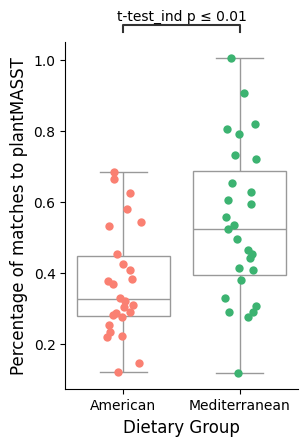

In [4]:
summed_df_merged = run_family_analysis('Oleaceae')

### Fabaceae

American vs. Mediterranean: t-test independent samples, P_val:2.851e-02 t=-2.257e+00


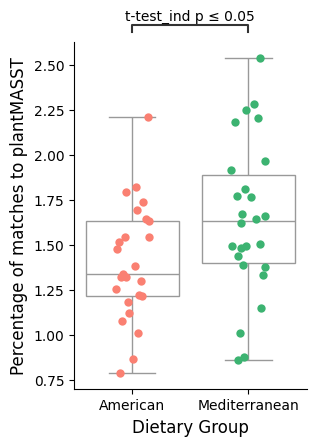

In [5]:
summed_df_merged = run_family_analysis('Fabaceae')